# Validasi Komprehensif ADIWAKO: Benchmark Functions & Perbandingan Varian PSO
**Rosa Nur Aliana Sawafi — 2311110008**  
Program Studi S1 Sains Data, Universitas Telkom Purwokerto

---
## Alur Eksperimen
1. Implementasi 6 algoritma PSO (Standard PSO + 3 varian baru + ADIWAKO-Original + ADIWAKO-Stable)
2. Benchmark Grup A — Reproduksi 7 fungsi Sekyere et al. (2024)
3. Benchmark Grup B — 8 fungsi Naser et al. (2024) yang sudah ada
4. Benchmark Grup C — 3 fungsi baru berdimensi tinggi (Rastrigin 30D, Zakharov 30D, Elliptic 20D)
5. Evaluasi lengkap: Optimum Value, Runtime, Mean Value, Standard Deviation + Convergence Curves

---
### Algoritma yang Dibandingkan

| No | Algoritma | Keterangan | Status di Jurnal Sekyere |
|---|---|---|---|
| 1 | **Standard PSO** | Kennedy & Eberhart (1995) | Sudah ada |
| 2 | **TVAC-PSO** | Time-Varying Acceleration Coefficients (Ratnaweera et al., 2004) | **Belum ada** |
| 3 | **WCPSO** | Constriction Factor PSO (Clerc & Kennedy, 2002) | **Belum ada** |
| 4 | **APSO** | Adaptive PSO berbasis success rate | **Belum ada** |
| 5 | **ADIWAKO-Original** | Formula murni Sekyere et al. (2024), tanpa modifikasi | Metode utama jurnal |
| 6 | **ADIWAKO-Stable** | Formula sama + stabilitas numerik Python | Implementasi penelitian ini |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Library berhasil diimport!')

Library berhasil diimport!


---
## BAGIAN 1: Implementasi Semua Algoritma

### Formula Masing-Masing Algoritma:

**Standard PSO:** `v = w*v + c1*r1*(pbest-x) + c2*r2*(gbest-x)`, w=0.729, c1=c2=1.494

**TVAC-PSO:** c1 menurun linear (c1_max→c1_min), c2 naik linear (c2_min→c2_max), w tetap  
`c1(t) = (c1_min-c1_max)*t/T + c1_max`, `c2(t) = (c2_max-c2_min)*t/T + c2_min`

**WCPSO (Constriction):** `v = chi*(v + c1*r1*(pbest-x) + c2*r2*(gbest-x))`  
`chi = 2/|2-phi-sqrt(phi^2-4*phi)|`, phi = c1+c2 > 4

**APSO (Adaptive):** w diperbarui berdasarkan success rate partikel per iterasi  
`w(t) = w_max - (w_max-w_min) * success_rate(t)`

**ADIWAKO-Original:** `w = mu*tanh(delta)`, `c1=c2 = mu*cosh(psi)` (Sekyere et al., 2024)

**ADIWAKO-Stable:** Sama dengan Original + velocity clamping + mu_min + c_clip_max

In [2]:
# ═══════════════════════════════════════════════════════════
# 1. Standard PSO — Kennedy & Eberhart (1995)
# ═══════════════════════════════════════════════════════════
class StandardPSO:
    def __init__(self, n_particles=500, max_iter=50,
                 w=0.729, c1=1.494, c2=1.494, bounds=None):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.w=w; self.c1=c1; self.c2=c2; self.bounds=bounds

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds]); ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost); gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]
        for _ in range(self.max_iter):
            r1=np.random.rand(self.n_particles,n_dim); r2=np.random.rand(self.n_particles,n_dim)
            vel=self.w*vel+self.c1*r1*(pbest_pos-pos)+self.c2*r2*(gbest_pos-pos)
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost; pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost: gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy()
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history


# ═══════════════════════════════════════════════════════════
# 2. TVAC-PSO — Time-Varying Acceleration Coefficients
#    Ratnaweera et al. (2004), IEEE Trans. Evol. Comput.
#    Belum ada di jurnal Sekyere et al. (2024)
# ═══════════════════════════════════════════════════════════
class TVAC_PSO:
    """
    Time-Varying Acceleration Coefficients PSO.
    c1 turun dari c1_max ke c1_min (eksplorasi berkurang seiring waktu).
    c2 naik dari c2_min ke c2_max (eksploitasi meningkat seiring waktu).
    Referensi: Ratnaweera et al. (2004)
    """
    def __init__(self, n_particles=500, max_iter=50,
                 w=0.729, c1_max=2.5, c1_min=0.5,
                 c2_min=0.5, c2_max=2.5, bounds=None):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.w=w
        self.c1_max=c1_max; self.c1_min=c1_min
        self.c2_min=c2_min; self.c2_max=c2_max
        self.bounds=bounds

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds]); ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost); gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]
        for t in range(1, self.max_iter+1):
            # c1 turun linear, c2 naik linear — Ratnaweera et al. Eq.(4)
            c1 = (self.c1_min-self.c1_max)*(t/self.max_iter) + self.c1_max
            c2 = (self.c2_max-self.c2_min)*(t/self.max_iter) + self.c2_min
            r1=np.random.rand(self.n_particles,n_dim); r2=np.random.rand(self.n_particles,n_dim)
            vel=self.w*vel+c1*r1*(pbest_pos-pos)+c2*r2*(gbest_pos-pos)
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost; pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost: gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy()
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history


# ═══════════════════════════════════════════════════════════
# 3. WCPSO — Constriction Factor PSO
#    Clerc & Kennedy (2002), IEEE Trans. Evol. Comput.
#    Belum ada di jurnal Sekyere et al. (2024)
# ═══════════════════════════════════════════════════════════
class WCPSO:
    """
    Constriction Factor PSO (Clerc & Kennedy, 2002).
    Menggunakan faktor konstriksi chi untuk menjamin konvergensi.
    chi = 2 / |2 - phi - sqrt(phi^2 - 4*phi)|, phi = c1 + c2 > 4
    Tidak memerlukan velocity clamping.
    """
    def __init__(self, n_particles=500, max_iter=50,
                 c1=2.05, c2=2.05, bounds=None):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.c1=c1; self.c2=c2; self.bounds=bounds
        phi = c1 + c2  # phi > 4
        self.chi = 2.0 / abs(2 - phi - np.sqrt(phi**2 - 4*phi))

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds]); ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost); gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]
        for _ in range(self.max_iter):
            r1=np.random.rand(self.n_particles,n_dim); r2=np.random.rand(self.n_particles,n_dim)
            # Clerc & Kennedy constriction formula
            vel=self.chi*(vel+self.c1*r1*(pbest_pos-pos)+self.c2*r2*(gbest_pos-pos))
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost; pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost: gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy()
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history


# ═══════════════════════════════════════════════════════════
# 4. APSO — Adaptive PSO berbasis success rate
#    Zhan et al. (2009), IEEE Trans. SMC
#    Belum ada di jurnal Sekyere et al. (2024)
# ═══════════════════════════════════════════════════════════
class APSO:
    """
    Adaptive PSO: w diperbarui berdasarkan success rate partikel.
    Jika banyak partikel berhasil meningkatkan pbest (success rate tinggi),
    w dikurangi untuk fokus eksploitasi. Sebaliknya, w dinaikkan untuk eksplorasi.
    Referensi: Zhan et al. (2009), disederhanakan.
    """
    def __init__(self, n_particles=500, max_iter=50,
                 w_max=0.9, w_min=0.4, c1=2.0, c2=2.0, bounds=None):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.w_max=w_max; self.w_min=w_min
        self.c1=c1; self.c2=c2; self.bounds=bounds

    def optimize(self, fitness_func, n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds]); ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost); gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]; w=self.w_max
        for _ in range(self.max_iter):
            r1=np.random.rand(self.n_particles,n_dim); r2=np.random.rand(self.n_particles,n_dim)
            vel=w*vel+self.c1*r1*(pbest_pos-pos)+self.c2*r2*(gbest_pos-pos)
            pos=np.clip(pos+vel,lb,ub)
            new_costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=new_costs<pbest_cost
            # Hitung success rate untuk adaptasi w
            success_rate=np.mean(better)
            # w turun jika banyak partikel sukses (fokus eksploitasi)
            # w naik jika sedikit yang sukses (perlu lebih eksplorasi)
            w = self.w_max - (self.w_max-self.w_min)*success_rate
            w = np.clip(w, self.w_min, self.w_max)
            pbest_pos[better]=pos[better].copy(); pbest_cost[better]=new_costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost: gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy()
            history.append(gbest_cost)
        return gbest_pos, gbest_cost, history


# ═══════════════════════════════════════════════════════════
# 5. ADIWAKO-Original — Sekyere et al. (2024) MURNI
# ═══════════════════════════════════════════════════════════
class ADIWAKO_Original:
    """Formula MURNI Sekyere et al. (2024) tanpa modifikasi."""
    def __init__(self, n_particles=500, max_iter=50,
                 W_max=1.0, W_min=0.1, C_max=5.0, C_min=2.0, bounds=None):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.W_max=W_max; self.W_min=W_min
        self.C_max=C_max; self.C_min=C_min; self.bounds=bounds

    def _params(self,t,pbest_costs,gbest_cost):
        safe=np.where(np.abs(pbest_costs)<1e-10,1e-10,pbest_costs)
        mu=np.clip((pbest_costs-gbest_cost)/safe,0,None)
        delta=self.W_max-(self.W_max-self.W_min)*t/self.max_iter
        w=mu*np.tanh(delta)
        psi=self.C_max-(self.C_max-self.C_min)*t/self.max_iter
        c=mu*np.cosh(psi)
        return w,c

    def optimize(self,fitness_func,n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds]); ub=np.array([b[1] for b in bounds])
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost); gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]
        for t in range(1,self.max_iter+1):
            w,c=self._params(t,pbest_cost,gbest_cost)
            w=w.reshape(-1,1); c=c.reshape(-1,1)
            r1=np.random.rand(self.n_particles,n_dim); r2=np.random.rand(self.n_particles,n_dim)
            vel=w*vel+c*r1*(pbest_pos-pos)+c*r2*(gbest_pos-pos)
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost; pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost: gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy()
            history.append(gbest_cost)
        return gbest_pos,gbest_cost,history


# ═══════════════════════════════════════════════════════════
# 6. ADIWAKO-Stable — Sekyere (2024) + stabilitas Python
# ═══════════════════════════════════════════════════════════
class ADIWAKO_Stable:
    """Formula IDENTIK Sekyere et al. (2024) + stabilitas numerik Python."""
    def __init__(self, n_particles=500, max_iter=50,
                 W_max=1.0, W_min=0.1, C_max=5.0, C_min=2.0,
                 bounds=None, mu_min=0.05, c_clip_max=4.0):
        self.n_particles=n_particles; self.max_iter=max_iter
        self.W_max=W_max; self.W_min=W_min
        self.C_max=C_max; self.C_min=C_min
        self.bounds=bounds; self.mu_min=mu_min; self.c_clip_max=c_clip_max

    def _params(self,t,pbest_costs,gbest_cost):
        safe=np.where(np.abs(pbest_costs)<1e-10,1e-10,pbest_costs)
        mu=np.clip((pbest_costs-gbest_cost)/safe,self.mu_min,None)
        delta=self.W_max-(self.W_max-self.W_min)*t/self.max_iter
        w=mu*np.tanh(delta)
        psi=self.C_max-(self.C_max-self.C_min)*t/self.max_iter
        c=np.clip(mu*np.cosh(psi),0,self.c_clip_max)
        return w,c

    def optimize(self,fitness_func,n_dim):
        bounds=self.bounds or [(-100,100)]*n_dim
        lb=np.array([b[0] for b in bounds]); ub=np.array([b[1] for b in bounds])
        v_max=0.2*(ub-lb)
        pos=lb+np.random.rand(self.n_particles,n_dim)*(ub-lb)
        vel=np.zeros((self.n_particles,n_dim))
        costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
        pbest_pos=pos.copy(); pbest_cost=costs.copy()
        gi=np.argmin(pbest_cost); gbest_pos=pbest_pos[gi].copy(); gbest_cost=pbest_cost[gi]
        history=[gbest_cost]
        for t in range(1,self.max_iter+1):
            w,c=self._params(t,pbest_cost,gbest_cost)
            w=w.reshape(-1,1); c=c.reshape(-1,1)
            r1=np.random.rand(self.n_particles,n_dim); r2=np.random.rand(self.n_particles,n_dim)
            vel=w*vel+c*r1*(pbest_pos-pos)+c*r2*(gbest_pos-pos)
            vel=np.clip(vel,-v_max,v_max)
            pos=np.clip(pos+vel,lb,ub)
            costs=np.array([fitness_func(pos[i]) for i in range(self.n_particles)])
            better=costs<pbest_cost; pbest_pos[better]=pos[better].copy(); pbest_cost[better]=costs[better]
            bi=np.argmin(pbest_cost)
            if pbest_cost[bi]<gbest_cost: gbest_cost=pbest_cost[bi]; gbest_pos=pbest_pos[bi].copy()
            history.append(gbest_cost)
        return gbest_pos,gbest_cost,history


print('Semua 6 algoritma berhasil didefinisikan!')
print()
print('Algoritma yang SUDAH ada di jurnal Sekyere: Standard PSO, ADIWAKO-Original')
print('Algoritma BARU (belum di jurnal)          : TVAC-PSO, WCPSO, APSO, ADIWAKO-Stable')

Semua 6 algoritma berhasil didefinisikan!

Algoritma yang SUDAH ada di jurnal Sekyere: Standard PSO, ADIWAKO-Original
Algoritma BARU (belum di jurnal)          : TVAC-PSO, WCPSO, APSO, ADIWAKO-Stable


---
## BAGIAN 2: Benchmark Functions

**Grup A** — 7 fungsi dari Sekyere et al. (2024)  
**Grup B** — 8 fungsi dari Naser et al. (2024) Top-25  
**Grup C** — 3 fungsi baru berdimensi tinggi (Rastrigin 30D, Zakharov 30D, Elliptic 20D)

In [3]:
# ── GRUP A: Sekyere et al. (2024) ──────────────────────────
def sum_squares(x):
    x=np.asarray(x,float); i=np.arange(1,len(x)+1); return np.sum(i*x**2)
def sphere(x):
    x=np.asarray(x,float); return np.sum(x**2)
def colville(x):
    x=np.asarray(x,float); x1,x2,x3,x4=x[0],x[1],x[2],x[3]
    return (100*(x1**2-x2)**2+(x1-1)**2+(x3-1)**2
            +90*(x3**2-x4)**2+10.1*((x2-1)**2+(x4-1)**2)+19.8*(x2-1)*(x4-1))
def matyas(x):
    x=np.asarray(x,float); return 0.26*(x[0]**2+x[1]**2)-0.48*x[0]*x[1]
def rosenbrock(x):
    x=np.asarray(x,float); return np.sum(100*(x[1:]-x[:-1]**2)**2+(1-x[:-1])**2)
def griewank(x):
    x=np.asarray(x,float); i=np.arange(1,len(x)+1)
    return np.sum(x**2)/4000-np.prod(np.cos(x/np.sqrt(i)))+1
def rot_hyperellipsoid(x):
    x=np.asarray(x,float); return sum(np.sum(x[:i+1]**2) for i in range(len(x)))

# ── GRUP B: Naser et al. (2024) Top-25 ─────────────────────
def rastrigin(x):
    x=np.asarray(x,float); return 10*len(x)+np.sum(x**2-10*np.cos(2*np.pi*x))
def styblinski_tang(x):
    x=np.asarray(x,float); return 0.5*np.sum(x**4-16*x**2+5*x)
def levy_n13(x):
    x=np.asarray(x,float); x1,x2=x[0],x[1]
    return (np.sin(3*np.pi*x1)**2+(x1-1)**2*(1+np.sin(3*np.pi*x2)**2)
            +(x2-1)**2*(1+np.sin(2*np.pi*x2)**2))
def schwefel_2_22(x):
    x=np.asarray(x,float); return np.sum(np.abs(x))+np.prod(np.abs(x))
def michalewicz(x,m=10):
    x=np.asarray(x,float); i=np.arange(1,len(x)+1)
    return -np.sum(np.sin(x)*(np.sin(i*x**2/np.pi))**(2*m))
def zakharov(x):
    x=np.asarray(x,float); i=np.arange(1,len(x)+1)
    s1=np.sum(x**2); s2=np.sum(0.5*i*x); return s1+s2**2+s2**4
def dixon_price(x):
    x=np.asarray(x,float)
    return (x[0]-1)**2+np.sum([(i+1)*(2*x[i]**2-x[i-1])**2 for i in range(1,len(x))])

# ── GRUP C: Fungsi Baru — Dimensi Tinggi ───────────────────
def elliptic(x):
    """
    High-conditioned Elliptic Function — Unimodal, ill-conditioned
    Range: [-100, 100] | f* = 0
    Karakteristik: skala tiap dimensi berbeda secara eksponensial
    → mekanisme adaptif ADIWAKO diharapkan unggul
    """
    x=np.asarray(x,float); n=len(x)
    if n==1: return x[0]**2
    i=np.arange(n); exponents=i/(n-1)
    return np.sum((1e6**exponents)*x**2)

# Rastrigin 30D dan Zakharov 30D menggunakan fungsi yang sama
# hanya dimensinya yang berbeda (dikonfigurasi di BENCH_C)

BENCH_A = [
    {'name':'g1-Sum Squares (5D)',       'func':sum_squares,      'n_dim':5,  'bounds':[(-10,10)]*5,         'optimum':0.0, 'type':'Unimodal',   'group':'A'},
    {'name':'g2-Sphere (20D)',            'func':sphere,           'n_dim':20, 'bounds':[(-100,100)]*20,      'optimum':0.0, 'type':'Unimodal',   'group':'A'},
    {'name':'g3-Colville (4D)',           'func':colville,         'n_dim':4,  'bounds':[(-10,10)]*4,         'optimum':0.0, 'type':'Multimodal', 'group':'A'},
    {'name':'g4-Matyas (2D)',             'func':matyas,           'n_dim':2,  'bounds':[(-10,10)]*2,         'optimum':0.0, 'type':'Unimodal',   'group':'A'},
    {'name':'g5-Rosenbrock (20D)',        'func':rosenbrock,       'n_dim':20, 'bounds':[(-5,10)]*20,         'optimum':0.0, 'type':'Multimodal', 'group':'A'},
    {'name':'g6-Griewank (2D)',           'func':griewank,         'n_dim':2,  'bounds':[(-600,600)]*2,       'optimum':0.0, 'type':'Multimodal', 'group':'A'},
    {'name':'g7-RotHyperEllipsoid (2D)',  'func':rot_hyperellipsoid,'n_dim':2, 'bounds':[(-65.536,65.536)]*2, 'optimum':0.0, 'type':'Unimodal',   'group':'A'},
]
BENCH_B = [
    {'name':'Rastrigin (2D)',       'func':rastrigin,     'n_dim':2,  'bounds':[(-5.12,5.12)]*2,  'optimum':0.0,    'type':'Multimodal', 'group':'B'},
    {'name':'Rastrigin (20D)',      'func':rastrigin,     'n_dim':20, 'bounds':[(-5.12,5.12)]*20, 'optimum':0.0,    'type':'Multimodal', 'group':'B'},
    {'name':'Styblinski-Tang (2D)', 'func':styblinski_tang,'n_dim':2, 'bounds':[(-5,5)]*2,        'optimum':-78.332,'type':'Multimodal', 'group':'B'},
    {'name':'Levy N.13 (2D)',       'func':levy_n13,      'n_dim':2,  'bounds':[(-10,10)]*2,      'optimum':0.0,    'type':'Multimodal', 'group':'B'},
    {'name':'Schwefel 2.22 (20D)',  'func':schwefel_2_22, 'n_dim':20, 'bounds':[(-10,10)]*20,     'optimum':0.0,    'type':'Unimodal',   'group':'B'},
    {'name':'Michalewicz (10D)',    'func':michalewicz,   'n_dim':10, 'bounds':[(0,np.pi)]*10,    'optimum':-9.66,  'type':'Multimodal', 'group':'B'},
    {'name':'Zakharov (20D)',       'func':zakharov,      'n_dim':20, 'bounds':[(-5,10)]*20,      'optimum':0.0,    'type':'Unimodal',   'group':'B'},
    {'name':'Dixon-Price (10D)',    'func':dixon_price,   'n_dim':10, 'bounds':[(-10,10)]*10,     'optimum':0.0,    'type':'Unimodal',   'group':'B'},
]
BENCH_C = [
    {'name':'Rastrigin (30D)',  'func':rastrigin, 'n_dim':30, 'bounds':[(-5.12,5.12)]*30,'optimum':0.0,'type':'Multimodal','group':'C',
     'justifikasi':'Perpanjangan kemenangan ADIWAKO-Stable di 20D — konfirmasi tren dimensi tinggi'},
    {'name':'Zakharov (50D)',   'func':zakharov,  'n_dim':50, 'bounds':[(-5,10)]*50,     'optimum':0.0,'type':'Unimodal',  'group':'C',
     'justifikasi':'Perpanjangan kemenangan ADIWAKO-Stable di 20D — konfirmasi tren dimensi tinggi'},
    {'name':'Elliptic (50D)',   'func':elliptic,  'n_dim':50, 'bounds':[(-100,100)]*50,  'optimum':0.0,'type':'Unimodal',  'group':'C',
     'justifikasi':'Ill-conditioned, skala dimensi eksponensial — mekanisme adaptif mu ADIWAKO diharapkan unggul'},
]
ALL_BENCH = BENCH_A + BENCH_B + BENCH_C

print(f'Total benchmark: {len(ALL_BENCH)} fungsi')
print(f'  Grup A (Sekyere 2024)  : {len(BENCH_A)} fungsi')
print(f'  Grup B (Naser 2024)    : {len(BENCH_B)} fungsi')
print(f'  Grup C (Baru - high-D) : {len(BENCH_C)} fungsi')
print()
print('Grup C — justifikasi pemilihan:')
for b in BENCH_C:
    print(f"  {b['name']:20s}: {b['justifikasi']}")

Total benchmark: 18 fungsi
  Grup A (Sekyere 2024)  : 7 fungsi
  Grup B (Naser 2024)    : 8 fungsi
  Grup C (Baru - high-D) : 3 fungsi

Grup C — justifikasi pemilihan:
  Rastrigin (30D)     : Perpanjangan kemenangan ADIWAKO-Stable di 20D — konfirmasi tren dimensi tinggi
  Zakharov (50D)      : Perpanjangan kemenangan ADIWAKO-Stable di 20D — konfirmasi tren dimensi tinggi
  Elliptic (50D)      : Ill-conditioned, skala dimensi eksponensial — mekanisme adaptif mu ADIWAKO diharapkan unggul


---
## BAGIAN 3: Konfigurasi & Eksperimen Benchmark

**Evaluasi mencakup:** Optimum Value, Runtime (detik), Mean Value, Standard Deviation

In [4]:
# ══════════════════════════════════════════════════════════
# PARAMETER EKSPERIMEN
# Sesuai jurnal Sekyere et al. (2024)
# ══════════════════════════════════════════════════════════
N_PARTICLES = 500
MAX_ITER    = 50
N_RUNS      = 10

ALGOS = [
    ('Standard PSO',     StandardPSO,      {'w':0.729,'c1':1.494,'c2':1.494}),
    ('WCPSO',            WCPSO,            {'c1':2.05,'c2':2.05}),
    ('APSO',             APSO,             {'w_max':0.9,'w_min':0.4,'c1':2.0,'c2':2.0}),
    ('ADIWAKO-Original', ADIWAKO_Original, {'W_max':1.0,'W_min':0.1,'C_max':5.0,'C_min':2.0}),
    ('ADIWAKO-Stable',   ADIWAKO_Stable,   {'W_max':1.0,'W_min':0.1,'C_max':5.0,'C_min':2.0,
                                             'mu_min':0.05,'c_clip_max':4.0}),
]

print(f'Parameter: n_particles={N_PARTICLES}, max_iter={MAX_ITER}, n_runs={N_RUNS}')
print(f'Algoritma: {len(ALGOS)} varian')
for name,_,_ in ALGOS:
    status = 'Sudah di jurnal Sekyere' if name in ['Standard PSO','ADIWAKO-Original'] else 'BARU'
    print(f'  {name:20s} [{status}]')

Parameter: n_particles=500, max_iter=50, n_runs=10
Algoritma: 5 varian
  Standard PSO         [Sudah di jurnal Sekyere]
  WCPSO                [BARU]
  APSO                 [BARU]
  ADIWAKO-Original     [Sudah di jurnal Sekyere]
  ADIWAKO-Stable       [BARU]


In [5]:
def run_benchmark(benchmark_list, n_runs=10, n_particles=500, max_iter=50):
    """
    Jalankan eksperimen benchmark dengan evaluasi lengkap:
    Optimum Value, Runtime, Mean Value, Standard Deviation
    """
    results = []
    for bench in benchmark_list:
        grp = bench.get('group','?')
        print(f"\n[Grup {grp}] {bench['name']} | {bench['type']}")
        print('  ' + '-'*65)

        for algo_name, AlgoClass, kw in ALGOS:
            run_costs = []; run_hists = []; run_times = []

            for run in range(n_runs):
                np.random.seed(run*7+13)
                algo = AlgoClass(n_particles=n_particles, max_iter=max_iter,
                                 bounds=bench['bounds'], **kw)
                t_start = time.time()
                _, best, hist = algo.optimize(bench['func'], bench['n_dim'])
                t_end   = time.time()

                run_costs.append(best)
                run_hists.append(hist)
                run_times.append(t_end - t_start)

            results.append({
                'Function'   : bench['name'],
                'Group'      : grp,
                'Type'       : bench['type'],
                'Algorithm'  : algo_name,
                'Optimum'    : np.min(run_costs),
                'Runtime'    : np.mean(run_times),
                'Mean'       : np.mean(run_costs),
                'Std'        : np.std(run_costs),
                'Theoretical': bench['optimum'],
                'History'    : np.mean(run_hists, axis=0),
            })
            print(f"  {algo_name:20s}| Opt:{np.min(run_costs):>10.3e} "
                  f"| Time:{np.mean(run_times):>6.2f}s "
                  f"| Mean:{np.mean(run_costs):>10.3e} "
                  f"| Std:{np.std(run_costs):>10.3e}")

    return results

print('Memulai eksperimen benchmark lengkap...')
print(f'Estimasi waktu: ~20-40 menit (6 algoritma x {len(ALL_BENCH)} fungsi x {N_RUNS} runs)')
print('Ganti N_PARTICLES=100 di cell sebelumnya untuk mempercepat testing\n')
all_results = run_benchmark(ALL_BENCH, n_runs=N_RUNS,
                            n_particles=N_PARTICLES, max_iter=MAX_ITER)
print('\nEksperimen selesai!')

Memulai eksperimen benchmark lengkap...
Estimasi waktu: ~20-40 menit (6 algoritma x 18 fungsi x 10 runs)
Ganti N_PARTICLES=100 di cell sebelumnya untuk mempercepat testing


[Grup A] g1-Sum Squares (5D) | Unimodal
  -----------------------------------------------------------------
  Standard PSO        | Opt: 3.862e-06 | Time:  0.05s | Mean: 4.403e-05 | Std: 2.582e-05
  WCPSO               | Opt: 8.818e-06 | Time:  0.05s | Mean: 3.344e-05 | Std: 1.461e-05
  APSO                | Opt: 3.552e-02 | Time:  0.05s | Mean: 2.352e-01 | Std: 1.807e-01
  ADIWAKO-Original    | Opt: 3.186e+00 | Time:  0.05s | Mean: 8.564e+00 | Std: 5.583e+00
  ADIWAKO-Stable      | Opt: 8.344e-02 | Time:  0.05s | Mean: 2.039e-01 | Std: 1.001e-01

[Grup A] g2-Sphere (20D) | Unimodal
  -----------------------------------------------------------------
  Standard PSO        | Opt: 1.273e+01 | Time:  0.04s | Mean: 2.824e+01 | Std: 1.212e+01
  WCPSO               | Opt: 1.367e+01 | Time:  0.04s | Mean: 3.195e+01 | Std: 

---
## BAGIAN 4: Tabel Evaluasi Lengkap

**Menampilkan: Optimum Value, Runtime (s), Mean Value, Standard Deviation**

In [6]:
def print_eval_table(group_label, group_id):
    """Cetak tabel evaluasi lengkap per grup — format mirip jurnal Sekyere."""
    algo_names = [a[0] for a in ALGOS]
    bench_list = [b for b in ALL_BENCH if b['group']==group_id]
    res_grp    = [r for r in all_results if r['Group']==group_id]

    rows = []
    for bench in bench_list:
        for algo in algo_names:
            r = next((x for x in res_grp
                      if x['Function']==bench['name'] and x['Algorithm']==algo), None)
            if r:
                rows.append({
                    'Fungsi'    : r['Function'],
                    'Tipe'      : r['Type'],
                    'Algoritma' : r['Algorithm'],
                    'Optimum'   : f"{r['Optimum']:.4e}",
                    'Runtime(s)': f"{r['Runtime']:.3f}",
                    'Mean'      : f"{r['Mean']:.4e}",
                    'Std Dev'   : f"{r['Std']:.4e}",
                    'Teoritik'  : r['Theoretical'],
                })

    df = pd.DataFrame(rows)
    print(f'\n{"="*80}')
    print(f'TABEL EVALUASI — {group_label}')
    print(f'{"="*80}')
    print(df.to_string(index=False))
    return df

df_A = print_eval_table('Grup A: Reproduksi Sekyere et al. (2024)', 'A')
df_B = print_eval_table('Grup B: Benchmark Tambahan Naser et al. (2024)', 'B')
df_C = print_eval_table('Grup C: Fungsi Baru Dimensi Tinggi', 'C')


TABEL EVALUASI — Grup A: Reproduksi Sekyere et al. (2024)
                   Fungsi       Tipe        Algoritma    Optimum Runtime(s)       Mean    Std Dev  Teoritik
      g1-Sum Squares (5D)   Unimodal     Standard PSO 3.8617e-06      0.052 4.4029e-05 2.5817e-05       0.0
      g1-Sum Squares (5D)   Unimodal            WCPSO 8.8177e-06      0.048 3.3443e-05 1.4612e-05       0.0
      g1-Sum Squares (5D)   Unimodal             APSO 3.5523e-02      0.048 2.3522e-01 1.8069e-01       0.0
      g1-Sum Squares (5D)   Unimodal ADIWAKO-Original 3.1861e+00      0.050 8.5636e+00 5.5826e+00       0.0
      g1-Sum Squares (5D)   Unimodal   ADIWAKO-Stable 8.3438e-02      0.049 2.0386e-01 1.0012e-01       0.0
          g2-Sphere (20D)   Unimodal     Standard PSO 1.2734e+01      0.041 2.8242e+01 1.2122e+01       0.0
          g2-Sphere (20D)   Unimodal            WCPSO 1.3665e+01      0.037 3.1952e+01 2.6732e+01       0.0
          g2-Sphere (20D)   Unimodal             APSO 4.4505e+03      0.040 9

### Tabel Ranking — Siapa Terbaik per Fungsi

In [7]:
algo_names = [a[0] for a in ALGOS]
wins = {a:{'optimum':0,'mean':0} for a in algo_names}

print(f'{"Fungsi":<28} {"Grp":^4} {"Tipe":^10} {"Terbaik-Optimum":^22} {"Terbaik-Mean":^22}')
print('='*90)
for bench in ALL_BENCH:
    fn   = bench['name']
    br   = [r for r in all_results if r['Function']==fn]
    bo   = min(br, key=lambda r: r['Optimum'])
    bm   = min(br, key=lambda r: r['Mean'])
    wins[bo['Algorithm']]['optimum'] += 1
    wins[bm['Algorithm']]['mean']    += 1
    print(f"{fn:<28} {bench['group']:^4} {bench['type']:^10} "
          f"{bo['Algorithm']:^22} {bm['Algorithm']:^22}")

print()
print('=== TOTAL KEMENANGAN (dari', len(ALL_BENCH), 'fungsi) ===')
print(f'{"Algoritma":<22} {"Optimum Terbaik":^18} {"Mean Terbaik":^15} {"Status Jurnal":^20}')
print('-'*78)
for name,_,_ in ALGOS:
    status = 'Ada di jurnal' if name in ['Standard PSO','ADIWAKO-Original'] else 'BARU'
    print(f'{name:<22} {wins[name]["optimum"]:^18} {wins[name]["mean"]:^15} {status:^20}')

Fungsi                       Grp     Tipe       Terbaik-Optimum          Terbaik-Mean     
g1-Sum Squares (5D)           A    Unimodal       Standard PSO              WCPSO         
g2-Sphere (20D)               A    Unimodal       Standard PSO           Standard PSO     
g3-Colville (4D)              A   Multimodal         WCPSO                  WCPSO         
g4-Matyas (2D)                A    Unimodal       Standard PSO           Standard PSO     
g5-Rosenbrock (20D)           A   Multimodal      Standard PSO           Standard PSO     
g6-Griewank (2D)              A   Multimodal      Standard PSO              WCPSO         
g7-RotHyperEllipsoid (2D)     A    Unimodal       Standard PSO              WCPSO         
Rastrigin (2D)                B   Multimodal      Standard PSO           Standard PSO     
Rastrigin (20D)               B   Multimodal      Standard PSO          ADIWAKO-Stable    
Styblinski-Tang (2D)          B   Multimodal     ADIWAKO-Stable         ADIWAKO-Stable    

### Tabel Perbandingan Runtime

In [8]:
# Hitung rata-rata runtime per algoritma
print('=== RATA-RATA RUNTIME PER ALGORITMA (detik) ===')
print(f'{"Algoritma":<22} {"Rata-rata Runtime":>18} {"Relatif vs PSO":>16}')
print('-'*58)

pso_avg = np.mean([r['Runtime'] for r in all_results if r['Algorithm']=='Standard PSO'])
for name,_,_ in ALGOS:
    avg = np.mean([r['Runtime'] for r in all_results if r['Algorithm']==name])
    rel = avg / pso_avg
    print(f'{name:<22} {avg:>18.3f}s {rel:>14.2f}x')

=== RATA-RATA RUNTIME PER ALGORITMA (detik) ===
Algoritma               Rata-rata Runtime   Relatif vs PSO
----------------------------------------------------------
Standard PSO                        0.072s           1.00x
WCPSO                               0.070s           0.97x
APSO                                0.072s           1.00x
ADIWAKO-Original                    0.072s           0.99x
ADIWAKO-Stable                      0.074s           1.02x


---
## BAGIAN 5: Convergence Curves

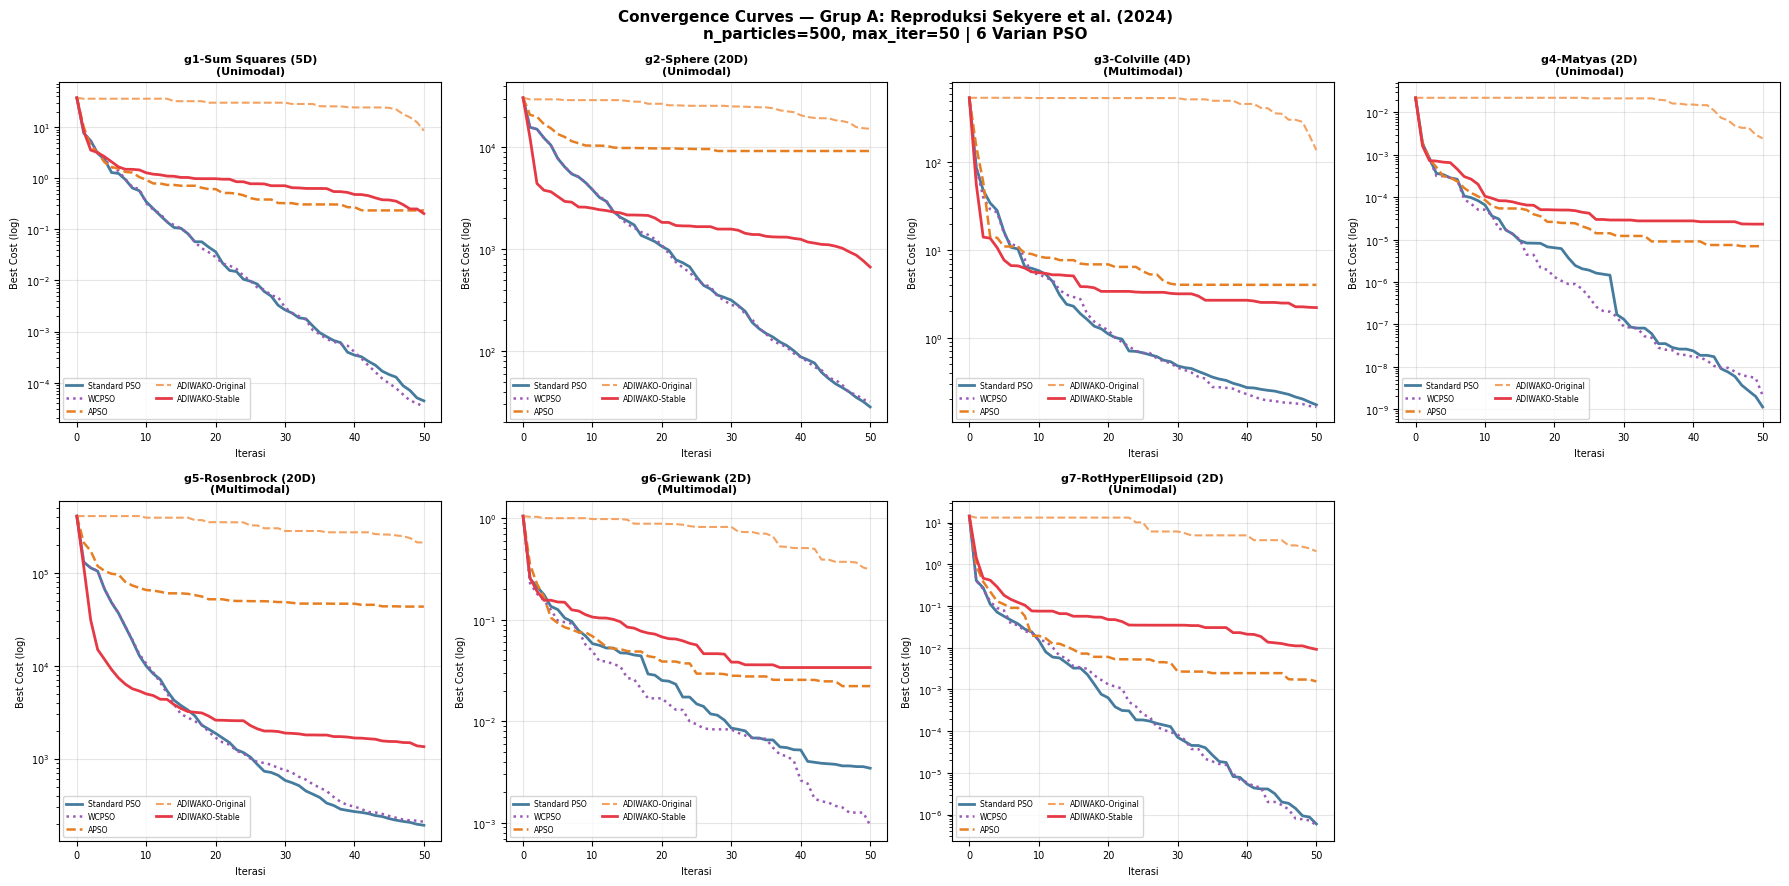

Tersimpan: conv_grupA.png


In [9]:
def plot_convergence_group(bench_list, results_list, title, fname):
    n=len(bench_list); ncols=4; nrows=int(np.ceil(n/ncols))
    fig,axes=plt.subplots(nrows,ncols,figsize=(18,4.5*nrows))
    axes=axes.flatten()

    # Warna dan gaya garis
    style = {
        'Standard PSO'    : {'color':'#457B9D', 'ls':'-',  'lw':2.0, 'label':'Standard PSO'},
        'WCPSO'           : {'color':'#9B59B6', 'ls':':',  'lw':1.8, 'label':'WCPSO'},
        'APSO'            : {'color':'#E67E22', 'ls':'--', 'lw':1.8, 'label':'APSO'},
        'ADIWAKO-Original': {'color':'#F4A261', 'ls':'--', 'lw':1.5, 'label':'ADIWAKO-Original'},
        'ADIWAKO-Stable'  : {'color':'#E63946', 'ls':'-',  'lw':2.0, 'label':'ADIWAKO-Stable'},
    }

    for idx,bench in enumerate(bench_list):
        ax=axes[idx]
        for r in results_list:
            if r['Function']==bench['name']:
                s=style.get(r['Algorithm'],{})
                h=np.abs(np.array(r['History']))+1e-300
                ax.semilogy(h, color=s.get('color','gray'),
                            ls=s.get('ls','-'), lw=s.get('lw',1.5),
                            label=s.get('label',r['Algorithm']))
        ax.set_title(f"{bench['name']}\n({bench['type']})",fontsize=8,fontweight='bold')
        ax.set_xlabel('Iterasi',fontsize=7); ax.set_ylabel('Best Cost (log)',fontsize=7)
        ax.legend(fontsize=5.5,ncol=2); ax.grid(True,alpha=0.3)
        ax.tick_params(labelsize=7)

    for i in range(n,len(axes)): axes[i].set_visible(False)
    plt.suptitle(title,fontsize=11,fontweight='bold')
    plt.tight_layout()
    plt.savefig(fname,dpi=150,bbox_inches='tight')
    plt.show(); print(f'Tersimpan: {fname}')

res_A=[r for r in all_results if r['Group']=='A']
plot_convergence_group(BENCH_A, res_A,
    f'Convergence Curves — Grup A: Reproduksi Sekyere et al. (2024)\n'
    f'n_particles={N_PARTICLES}, max_iter={MAX_ITER} | 6 Varian PSO',
    'conv_grupA.png')

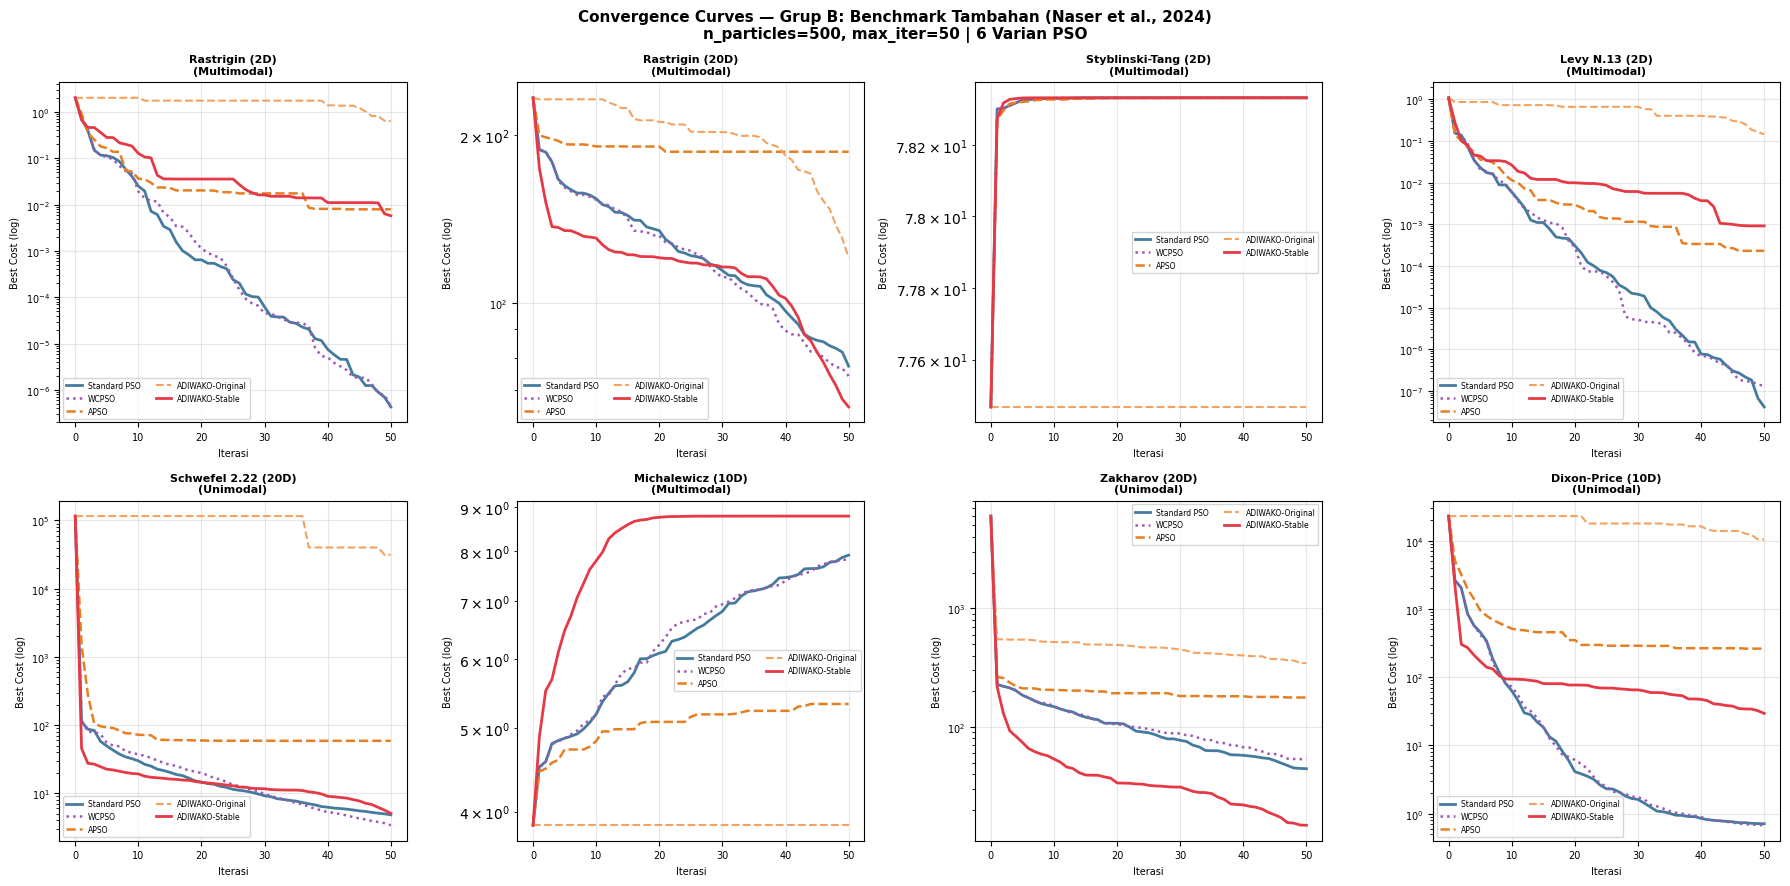

Tersimpan: conv_grupB.png


In [10]:
res_B=[r for r in all_results if r['Group']=='B']
plot_convergence_group(BENCH_B, res_B,
    f'Convergence Curves — Grup B: Benchmark Tambahan (Naser et al., 2024)\n'
    f'n_particles={N_PARTICLES}, max_iter={MAX_ITER} | 6 Varian PSO',
    'conv_grupB.png')

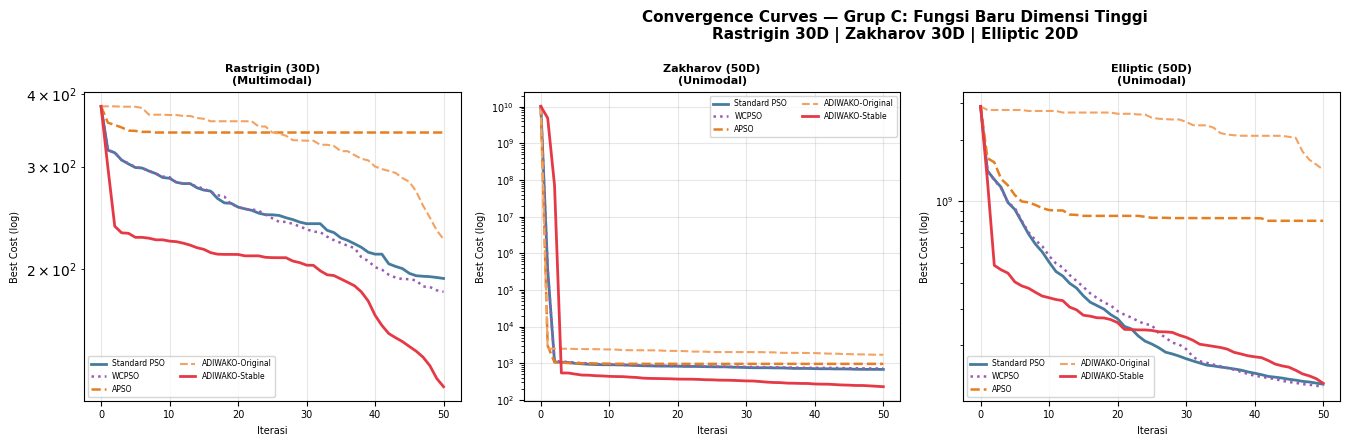

Tersimpan: conv_grupC.png


In [11]:
res_C=[r for r in all_results if r['Group']=='C']
plot_convergence_group(BENCH_C, res_C,
    f'Convergence Curves — Grup C: Fungsi Baru Dimensi Tinggi\n'
    f'Rastrigin 30D | Zakharov 30D | Elliptic 20D',
    'conv_grupC.png')

### Bar Chart Perbandingan Optimum Value (log scale)

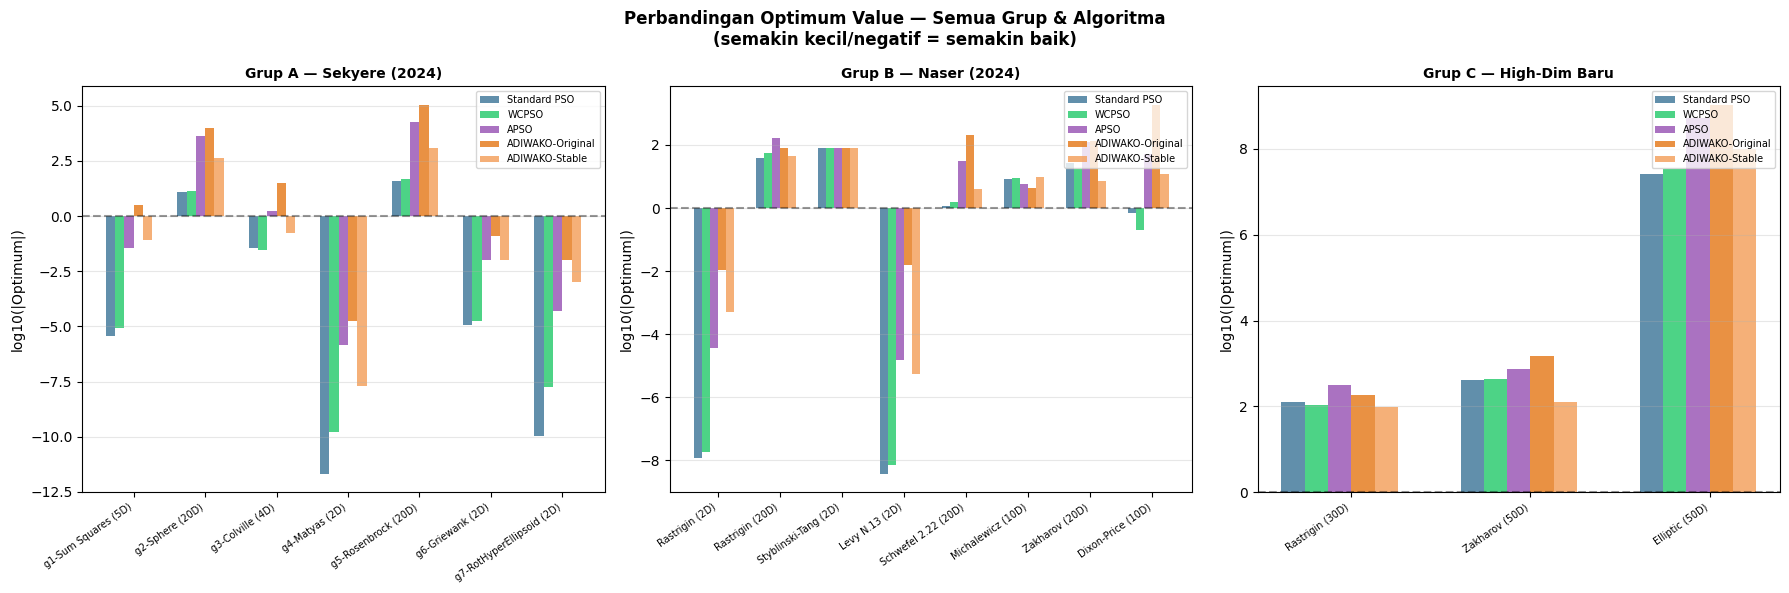

Tersimpan: comparison_all.png


In [12]:
fig,axes=plt.subplots(1,3,figsize=(18,6))
algo_names=[a[0] for a in ALGOS]
colors_bar=['#457B9D','#2ECC71','#9B59B6','#E67E22','#F4A261','#E63946']

for ax_idx,(ax,bench_list,grp,title) in enumerate(zip(
    axes,
    [BENCH_A, BENCH_B, BENCH_C],
    ['A','B','C'],
    ['Grup A — Sekyere (2024)','Grup B — Naser (2024)','Grup C — High-Dim Baru']
)):
    fn_names=[b['name'] for b in bench_list]
    x=np.arange(len(fn_names)); w=0.13
    res_grp=[r for r in all_results if r['Group']==grp]

    for mi,(algo,color) in enumerate(zip(algo_names,colors_bar)):
        vals=[]
        for fn in fn_names:
            r=next((r for r in res_grp if r['Function']==fn and r['Algorithm']==algo),None)
            vals.append(np.log10(abs(r['Optimum'])+1e-300) if r else 0)
        ax.bar(x+mi*w, vals, w, label=algo, color=color, alpha=0.85)

    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xticks(x+w*2.5)
    ax.set_xticklabels(fn_names, rotation=35, ha='right', fontsize=7)
    ax.set_ylabel('log10(|Optimum|)')
    ax.legend(fontsize=7,loc='upper right')
    ax.grid(axis='y',alpha=0.3)
    ax.axhline(y=0,color='black',ls='--',alpha=0.4)

plt.suptitle('Perbandingan Optimum Value — Semua Grup & Algoritma\n(semakin kecil/negatif = semakin baik)',
             fontsize=12,fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_all.png',dpi=150,bbox_inches='tight')
plt.show(); print('Tersimpan: comparison_all.png')

---
## BAGIAN 6: Ringkasan & Temuan Utama

In [13]:
print('='*75)
print('RINGKASAN EKSPERIMEN BENCHMARK')
print(f'Parameter: n_particles={N_PARTICLES}, max_iter={MAX_ITER}, n_runs={N_RUNS}')
print('='*75)

for grp,label,bench_list in [
    ('A','Reproduksi Sekyere et al.',BENCH_A),
    ('B','Benchmark Tambahan Naser et al.',BENCH_B),
    ('C','Fungsi Baru High-Dimension',BENCH_C)
]:
    print(f'\n--- Grup {grp}: {label} ---')
    header = f'{"Fungsi":<28}'
    for name,_,_ in ALGOS:
        header += f' {name[:12]:>13}'
    print(header)
    print('-'*105)

    res_grp=[r for r in all_results if r['Group']==grp]
    for bench in bench_list:
        fn=bench['name']
        line=f'{fn:<28}'
        opts={}
        for name,_,_ in ALGOS:
            r=next((x for x in res_grp if x['Function']==fn and x['Algorithm']==name),None)
            val=r['Optimum'] if r else float('nan')
            opts[name]=val
            line+=f' {val:>13.3e}'
        # Tandai pemenang
        best_algo=min(opts,key=lambda k:opts[k])
        print(line + f'  <- {best_algo}')

print()
print('='*75)
print('TOTAL KEMENANGAN (Optimum Value)')
print('='*75)
for name,_,_ in ALGOS:
    w=wins[name]['optimum']
    bar='#'*w + '.'*(len(ALL_BENCH)-w)
    print(f'{name:<22} [{bar}] {w}/{len(ALL_BENCH)}')

RINGKASAN EKSPERIMEN BENCHMARK
Parameter: n_particles=500, max_iter=50, n_runs=10

--- Grup A: Reproduksi Sekyere et al. ---
Fungsi                        Standard PSO         WCPSO          APSO  ADIWAKO-Orig  ADIWAKO-Stab
---------------------------------------------------------------------------------------------------------
g1-Sum Squares (5D)              3.862e-06     8.818e-06     3.552e-02     3.186e+00     8.344e-02  <- Standard PSO
g2-Sphere (20D)                  1.273e+01     1.367e+01     4.450e+03     1.024e+04     4.168e+02  <- Standard PSO
g3-Colville (4D)                 3.590e-02     2.994e-02     1.657e+00     3.138e+01     1.689e-01  <- WCPSO
g4-Matyas (2D)                   2.069e-12     1.675e-10     1.416e-06     1.817e-05     1.972e-08  <- Standard PSO
g5-Rosenbrock (20D)              3.985e+01     4.941e+01     1.863e+04     1.136e+05     1.167e+03  <- Standard PSO
g6-Griewank (2D)                 1.225e-05     1.709e-05     9.921e-03     1.315e-01     1.085e-0